In [1]:
import polars as pl

assay_type = pl.read_parquet(
    "/tgen_labs/altin/alphafold3/workspace/tcrtrifold-experiments/data/iedb_meta/assay_type.parquet"
)

iedb_II = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.conf_af3.parquet"
)

iedb_II_n = iedb_II.filter(~pl.col("cognate")).explode("receptor_id")

iedb_II_at = (
    iedb_II.filter(pl.col("cognate"))
    .explode("receptor_id")
    .join(assay_type, on="receptor_id")
)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn import metrics
from typing import Sequence, Tuple


def violin_abs_feature_multi(
    features_list: Sequence[np.ndarray],
    cognate_flags_list: Sequence[np.ndarray],
    labels: Sequence[str],
    figsize: Tuple[int, int] | None = None,
):
    """
    Grouped violin plots of |feature| for cognates vs noncognates across multiple assay types.
    Annotates the ROC AUC per label (using |feature| as the score).

    Parameters
    ----------
    features_list : list of 1D arrays (float)
        Feature values per label.
    cognate_flags_list : list of 1D bool arrays
        True=cognate, aligned with features_list.
    labels : list of str
        Assay type names (one per pair of violins).
    figsize : optional (w, h)

    Returns
    -------
    fig, ax
    """
    if not (len(features_list) == len(cognate_flags_list) == len(labels)):
        raise ValueError(
            "features_list, cognate_flags_list, and labels must have equal length"
        )

    n = len(labels)
    if figsize is None:
        figsize = (max(6, 2 * n + 4), 6)

    non_lists, cog_lists, aucs = [], [], []

    # Build distributions and AUCs per label
    for x, y in zip(features_list, cognate_flags_list):
        x = np.asarray(x, dtype=float).ravel()
        y = np.asarray(y, dtype=bool).ravel()
        if x.size != y.size:
            raise ValueError(
                "Each features array must match length of its cognate flag array"
            )

        finite = np.isfinite(x)
        x_abs = np.abs(x[finite])
        y_f = y[finite]

        cog_vals = x_abs[y_f]
        non_vals = x_abs[~y_f]

        non_lists.append(non_vals)
        cog_lists.append(cog_vals)

        # Compute ROC AUC using |feature| as score (higher assumed more cognate-like)
        if cog_vals.size > 0 and non_vals.size > 0:
            scores = np.concatenate([cog_vals, non_vals])
            labels_bin = np.concatenate(
                [np.ones_like(cog_vals, dtype=int), np.zeros_like(non_vals, dtype=int)]
            )
            fpr, tpr, _ = metrics.roc_curve(labels_bin, scores)
            auc_val = float(metrics.auc(fpr, tpr))
        else:
            auc_val = np.nan
        aucs.append(auc_val)

    # Prepare violin positions: [non0, cog0,  non1, cog1,  ...]
    data = []
    positions = []
    base = 0.0
    step = 3.0
    width = 0.8

    for i in range(n):
        data.extend([non_lists[i], cog_lists[i]])
        positions.extend([base + 0.0, base + 1.0])
        base += step

    fig, ax = plt.subplots(figsize=figsize)

    parts = ax.violinplot(
        data,
        positions=positions,
        showmeans=False,
        showmedians=True,
        widths=width,
    )

    # Color bodies
    non_color = "lightgray"
    cog_color = "tab:blue"
    for idx, body in enumerate(parts["bodies"]):
        is_non = idx % 2 == 0
        body.set_facecolor(non_color if is_non else cog_color)
        body.set_alpha(0.7)
        body.set_edgecolor("black")
        body.set_linewidth(0.6)

    if "cmedians" in parts:
        parts["cmedians"].set_linewidth(1.2)

    # Axes & legend
    mid_positions = [positions[2 * i] + 0.5 for i in range(n)]
    ax.set_xticks(mid_positions, labels=labels)
    ax.set_xlim(min(positions) - 1.0, max(positions) + 1.0)
    ax.set_ylabel("|feature|")
    ax.set_title("Cognate vs Noncognate |feature| by assay type")

    ax.legend(
        handles=[
            Patch(facecolor=non_color, label="noncognate"),
            Patch(facecolor=cog_color, label="cognate"),
        ],
        loc="lower right",
        frameon=True,
    )

    # AUC annotations per group
    ymin, ymax = ax.get_ylim()
    y_text = ymax - 0.03 * (ymax - ymin)
    for i, auc_val in enumerate(aucs):
        txt = (
            f"AUC = {auc_val:.3f}\ncog={len(cog_lists[i])}\nnoncog={len(non_lists[i])}"
            if np.isfinite(auc_val)
            else "AUC = NA"
        )
        ax.text(
            mid_positions[i],
            y_text,
            txt,
            ha="center",
            va="top",
            fontsize="small",
            bbox=dict(boxstyle="round,pad=0.25", alpha=0.25),
        )

    return fig, ax

3H-thymidine mean AUC: 0.5690776875266236
51 chromium mean AUC: 0.6833333333333332
CFSE mean AUC: 0.5510827976737068
ELISA mean AUC: 0.708239087301587
ELISPOT mean AUC: 0.635
ICS mean AUC: 0.45499999999999996
binding assay mean AUC: 0.5945
bioassay mean AUC: 0.7574074074074074
biological activity mean AUC: 0.7143721152517539
cytometric bead array mean AUC: 0.33768382352941173
in vitro assay mean AUC: 0.775
in vivo assay mean AUC: 0.5357142857142858
intracellular staining mean AUC: 0.35000000000000003
multimer/tetramer mean AUC: 0.5193370537999651
reporter gene assay mean AUC: 0.6268939393939393
surface plasmon resonance (SPR) mean AUC: 0.7838541666666666
x-ray crystallography mean AUC: 0.7741319444444444


(<Figure size 3800x600 with 1 Axes>,
 <Axes: title={'center': 'Cognate vs Noncognate |feature| by assay type'}, ylabel='|feature|'>)

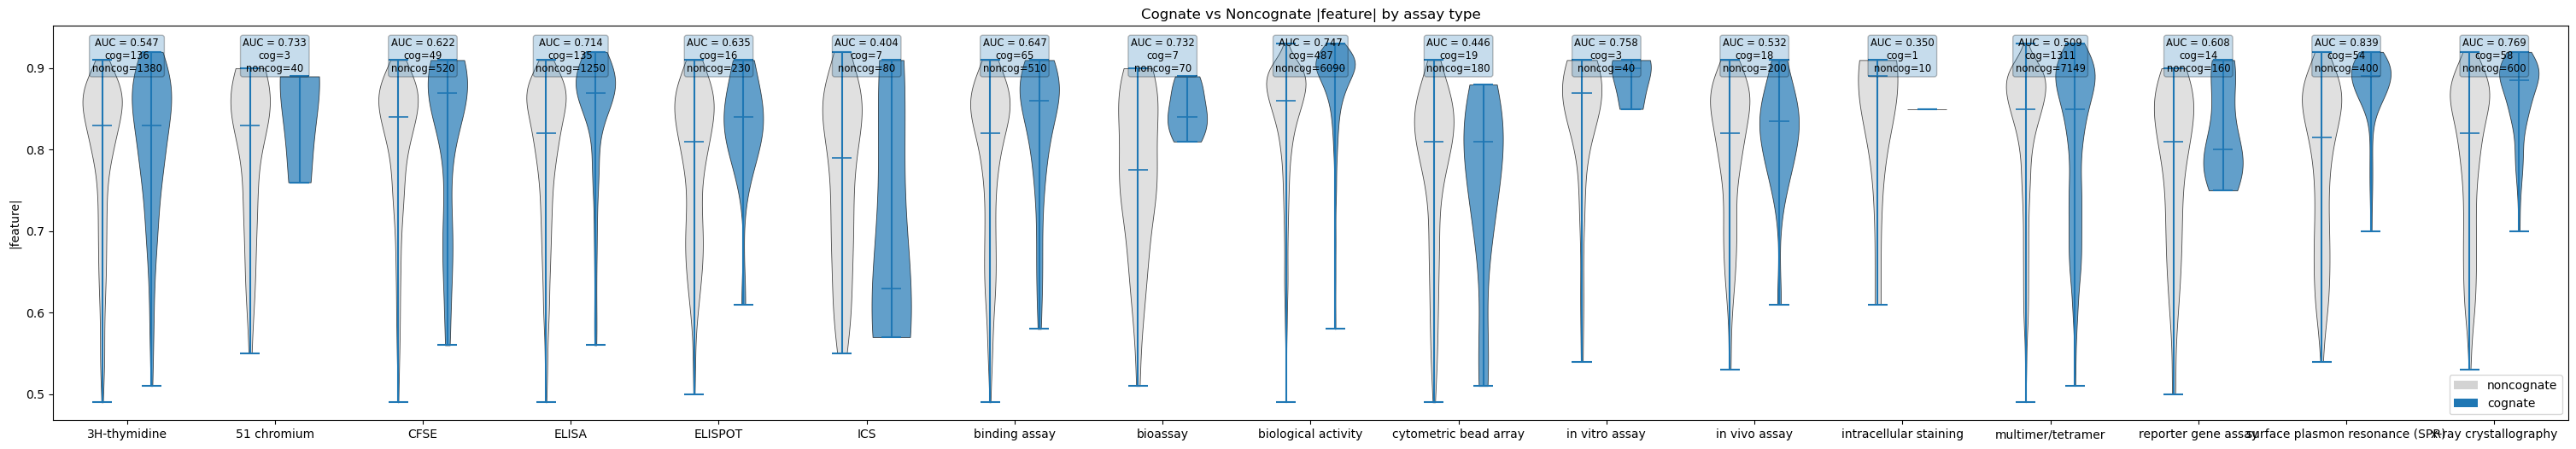

In [3]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
from tcrtrifold.eval_utils import antigen_raw_score_auc

featname = "iptm"

at_p = iedb_II_at.sort(by="assay_type").partition_by("assay_type", maintain_order=True)

feat = []
cog = []
lab = []

for p in at_p:
    at = p.select("assay_type")[0].item()

    focal_triad = pl.concat(
        [
            p.select(pl.exclude("assay_type")),
            iedb_II_n.join(
                p.select(FORMAT_ANTIGEN_COLS).unique(),
                on=FORMAT_ANTIGEN_COLS,
                how="inner",
            ),
        ]
    )

    auc_df = antigen_raw_score_auc(focal_triad, featname)

    feat.append(focal_triad.select(featname).to_series().to_numpy())
    cog.append(focal_triad.select("cognate").to_series().to_numpy())
    lab.append(at)

    mean_auc = auc_df.select(pl.col("roc_auc").mean()).item()
    print(f"{at} mean AUC: {mean_auc}")

violin_abs_feature_multi(feat, cog, lab)

In [ ]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
from tcrtrifold.eval_utils import antigen_raw_score_auc

featname = "iptm"

hla_p = iedb_II.sort(by="assay_type").partition_by("assay_type", maintain_order=True)

feat = []
cog = []
lab = []

for p in at_p:
    at = p.select("assay_type")[0].item()

    focal_triad = pl.concat(
        [
            p.select(pl.exclude("assay_type")),
            iedb_II_n.join(
                p.select(FORMAT_ANTIGEN_COLS).unique(),
                on=FORMAT_ANTIGEN_COLS,
                how="inner",
            ),
        ]
    )

    auc_df = antigen_raw_score_auc(focal_triad, featname)

    feat.append(focal_triad.select(featname).to_series().to_numpy())
    cog.append(focal_triad.select("cognate").to_series().to_numpy())
    lab.append(at)

    mean_auc = auc_df.select(pl.col("roc_auc").mean()).item()
    print(f"{at} mean AUC: {mean_auc}")

violin_abs_feature_multi(feat, cog, lab)